In [9]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

/Users/sophie/Seaglider/SeagliderData/DataManagement


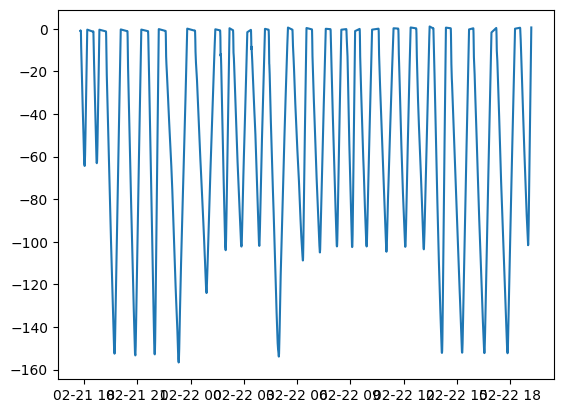

In [10]:
print(os.getcwd())
times_ds = xr.open_dataset('sg175_TimeSeriesTest_timeseries.nc')

times_ds.time.values[0]

time = times_ds.time.values
depth = times_ds.depth.values
plt.plot(time, -depth)

In [11]:
display(times_ds)

<xarray.Dataset> Size: 948kB
Dimensions:                    (gps_info: 72, sg_data_point: 6652,
                                trajectory: 24, dive: 24)
Coordinates:
    ctd_time                   (sg_data_point) datetime64[ns] 53kB ...
    ctd_depth                  (sg_data_point) float32 27kB ...
    latitude                   (sg_data_point) float32 27kB ...
    longitude                  (sg_data_point) float32 27kB ...
  * trajectory                 (trajectory) int32 96B 1 2 3 4 5 ... 21 22 23 24
Dimensions without coordinates: gps_info, sg_data_point, dive
Data variables: (12/57)
    gps_info_dive_number       (gps_info) int32 288B ...
    sg_data_point_dive_number  (sg_data_point) int32 27kB ...
    log_gps_time               (gps_info) datetime64[ns] 576B ...
    time                       (sg_data_point) datetime64[ns] 53kB 2025-02-21...
    pressure                   (sg_data_point) float32 27kB ...
    depth                      (sg_data_point) float32 27kB 0.8584 ... -0.6588
    ...                         ...
    end_longitude              (dive) float32 96B ...
    depth_avg_curr_east        (dive) float32 96B ...
    depth_avg_curr_north       (dive) float32 96B ...
    depth_avg_curr_qc          (dive) |S1 24B ...
    latlong_qc                 (dive) |S1 24B ...
    glider                     |S12 12B ...
Attributes: (12/47)
    project:                         TimeSeriesTest
    title:                           Physical and chemical data collected fro...
    summary:                         SG175 TimeSeriesTest
    source:                          Seaglider SG175
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2025-02-22T19:02:20Z
    uuid:                            325d80c4-f152-11ef-b0bd-a3c289f51d9b
    base_station_version:            3.0.2
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6

In [12]:
times_ds.time.values[0]

np.datetime64('2025-02-21T17:47:28.464000000')

In [13]:
print(os.getcwd())

#Select the relevant variables
new_times_ds = times_ds[['time', 'depth', 'latitude', 'longitude','temperature', 'salinity']]
#Convert to DataFrame and save
new_times_ds.to_dataframe().reset_index().to_csv('sg175_TimeSeriesTest_timeseries_cleaned.csv', index=False)
new_times_ds.to_netcdf('sg175_TimeSeriesTest_timeseries_cleaned.nc')
display(new_times_ds)

/Users/sophie/Seaglider/SeagliderData/DataManagement


<xarray.Dataset> Size: 266kB
Dimensions:      (sg_data_point: 6652)
Coordinates:
    latitude     (sg_data_point) float32 27kB 47.72 47.72 47.72 ... 47.72 47.72
    longitude    (sg_data_point) float32 27kB -122.4 -122.4 ... -122.4 -122.4
    ctd_time     (sg_data_point) datetime64[ns] 53kB 2025-02-21T17:47:28.4640...
    ctd_depth    (sg_data_point) float32 27kB 0.2648 0.2445 ... 2.11 -0.5544
Dimensions without coordinates: sg_data_point
Data variables:
    time         (sg_data_point) datetime64[ns] 53kB 2025-02-21T17:47:28.4640...
    depth        (sg_data_point) float32 27kB 0.8584 0.8384 ... 2.046 -0.6588
    temperature  (sg_data_point) float32 27kB 8.626 8.621 8.617 ... 8.619 8.642
    salinity     (sg_data_point) float32 27kB nan nan nan nan ... 29.37 nan nan
Attributes: (12/47)
    project:                         TimeSeriesTest
    title:                           Physical and chemical data collected fro...
    summary:                         SG175 TimeSeriesTest
    source:                          Seaglider SG175
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2025-02-22T19:02:20Z
    uuid:                            325d80c4-f152-11ef-b0bd-a3c289f51d9b
    base_station_version:            3.0.2
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6

In [14]:
times_ds = xr.open_dataset('sg175_TimeSeriesTest_timeseries.nc')

times_ds['U_DAC'] = times_ds['depth_avg_curr_east']
times_ds['V_DAC'] = times_ds['depth_avg_curr_north']

# add metadata
times_ds['U_DAC'].attrs['pre_cleaning_name'] = 'depth_avg_curr_east'
times_ds['V_DAC'].attrs['pre_cleaning_name'] = 'depth_avg_curr_north'

#Select the relevant variables
new_times_ds = times_ds[['U_DAC', 'V_DAC', 'start_time', 'end_time', 'start_latitude', 'end_latitude', 'start_longitude', 'end_longitude']]
display(new_times_ds)

#Convert to DataFrame and save
new_times_ds.to_dataframe().reset_index().to_csv('sg175_TimeSeriesTest_DAC_timeseries_cleaned.csv', index=False)
new_times_ds.to_netcdf('sg175_TimeSeriesTest_DAC_timeseries_cleaned.nc')


<xarray.Dataset> Size: 960B
Dimensions:          (dive: 24)
Dimensions without coordinates: dive
Data variables:
    U_DAC            (dive) float32 96B ...
    V_DAC            (dive) float32 96B ...
    start_time       (dive) datetime64[ns] 192B ...
    end_time         (dive) datetime64[ns] 192B ...
    start_latitude   (dive) float32 96B ...
    end_latitude     (dive) float32 96B ...
    start_longitude  (dive) float32 96B ...
    end_longitude    (dive) float32 96B ...
Attributes: (12/47)
    project:                         TimeSeriesTest
    title:                           Physical and chemical data collected fro...
    summary:                         SG175 TimeSeriesTest
    source:                          Seaglider SG175
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2025-02-22T19:02:20Z
    uuid:                            325d80c4-f152-11ef-b0bd-a3c289f51d9b
    base_station_version:            3.0.2
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6